In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../Data/Train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,C,Flight,2,5,306,6,high,M,45,3838,1
1,2,F,Ship,7,2,114,3,high,M,35,2710,1
2,3,B,Ship,7,2,215,7,medium,F,44,4152,0
3,4,A,Road,5,3,126,5,medium,M,54,2245,0
4,5,F,Ship,3,5,113,3,medium,M,43,1806,1


In [3]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [4]:
X = df[['Cost_of_the_Product', 'Weight_in_gms']]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

S:\C\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [7]:
print("Cluster Centers:\n", kmeans.cluster_centers_)

Cluster Centers:
 [[ 0.8871159   0.67260173]
 [-0.96422994  0.60407436]
 [ 0.03710863 -1.06490181]]


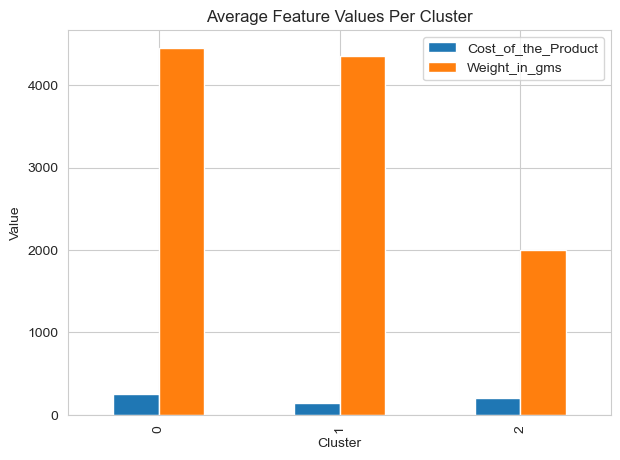

In [8]:
cluster_summary = df.groupby('Cluster')[['Cost_of_the_Product','Weight_in_gms']].mean()

cluster_summary.plot(kind='bar', figsize=(7,5))

plt.title("Average Feature Values Per Cluster")
plt.ylabel("Value")
plt.xlabel("Cluster")

plt.show()

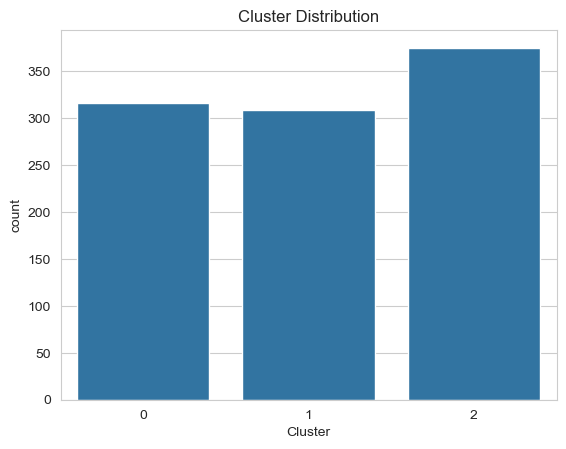

In [9]:
sns.countplot(x=df['Cluster'])

plt.title("Cluster Distribution")
plt.show()

In [10]:
X_features = df.drop(['Reached.on.Time_Y.N'], axis=1)
y = df['Reached.on.Time_Y.N']

X_features = pd.get_dummies(X_features, drop_first=True)

selector = SelectKBest(score_func=f_classif, k=5)

X_new = selector.fit_transform(X_features, y)

selected_features = X_features.columns[selector.get_support()]

print("Top 5 Features:")
print(selected_features)

Top 5 Features:
Index(['Weight_in_gms', 'Cluster', 'Warehouse_block_F',
       'Mode_of_Shipment_Ship', 'Product_importance_medium'],
      dtype='object')
